# Feature-Bicubic-Decode vs Quaternion-Bicubic (Three Test Samples)

This notebook uses:
- `dataset_root = /data/warren/materials/EBSD/Ti_Al_1pct_QSR_x4`
- first 3 `Test` samples

and runs two pipelines:
1. **Feature space:** encode LR quaternions to A1 features, bicubic interpolate features, decode to HR quaternions.
2. **Quaternion space:** bicubic interpolate quaternion channels directly.

Then it compares both against the HR target using angular error maps/statistics.

In [1]:
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'training').is_dir() and (p / 'models').is_dir() and (p / 'experiments').is_dir():
            return p
    raise FileNotFoundError(
        "Could not find repo root containing training/, models/, and experiments/. "
        f"Started from: {start}"
    )


REPO_ROOT = find_repo_root(Path.cwd())

DATASET_ROOT = Path('/data/home/umang/Materials/Materials_data_mount/datasets/Ti_Al_1pct_QSR_x4')
EXP_CONFIG = REPO_ROOT / 'experiments/Ti_Al_1pct/iso_embedding_sr_attn_a1_masked_hcp_01/config.json'
CHECKPOINT = REPO_ROOT / 'experiments/Ti_Al_1pct/iso_embedding_sr_attn_a1_masked_hcp_01/checkpoints/best_model.pt'

SPLIT = 'Test'
SAMPLE_INDEX = 0
NUM_TEST_PLOTS = 10

# Decoder control:
# By default, force model.decoder.{steps,num_starts} to match config.
ENFORCE_CONFIG_DECODER_SETTINGS = True

# Optional manual overrides. Leave as None to use config values.
DECODER_STEPS_OVERRIDE = None
DECODER_NUM_STARTS_OVERRIDE = None

OUTPUT_DIR = REPO_ROOT / 'out/notebook_feature_vs_quat_bicubic'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'REPO_ROOT:    {REPO_ROOT}')
print(f'DATASET_ROOT: {DATASET_ROOT}')
print(f'EXP_CONFIG:   {EXP_CONFIG}')
print(f'CHECKPOINT:   {CHECKPOINT}')

REPO_ROOT:    /data/home/umang/Materials/Reynolds-QSR
DATASET_ROOT: /data/home/umang/Materials/Materials_data_mount/datasets/Ti_Al_1pct_QSR_x4
EXP_CONFIG:   /data/home/umang/Materials/Reynolds-QSR/experiments/Ti_Al_1pct/iso_embedding_sr_attn_a1_masked_hcp_01/config.json
CHECKPOINT:   /data/home/umang/Materials/Reynolds-QSR/experiments/Ti_Al_1pct/iso_embedding_sr_attn_a1_masked_hcp_01/checkpoints/best_model.pt


In [2]:
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'training').is_dir() and (p / 'models').is_dir() and (p / 'experiments').is_dir():
            return p
    raise FileNotFoundError(
        "Could not find repo root containing training/, models/, and experiments/. "
        f"Started from: {start}"
    )


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from training.config_utils import load_and_prepare_config
from training.quaternion_dataset import QuaternionDataset
from utils.runtime_helpers import build_iso_embedding_sr_attn_from_config, load_checkpoint_state_compat

torch.set_grad_enabled(True)


def to_hwc_quat(q: torch.Tensor) -> torch.Tensor:
    """Convert quaternion image to (H, W, 4)."""
    if q.dim() != 3:
        raise ValueError(f'Expected rank-3 tensor, got {tuple(q.shape)}')
    if q.shape[-1] == 4:
        return q
    if q.shape[0] == 4:
        return q.permute(1, 2, 0)
    raise ValueError(f'Could not find quaternion channel axis in shape {tuple(q.shape)}')


def to_chw_quat(q: torch.Tensor) -> torch.Tensor:
    """Convert quaternion image to (4, H, W)."""
    if q.dim() != 3:
        raise ValueError(f'Expected rank-3 tensor, got {tuple(q.shape)}')
    if q.shape[0] == 4:
        return q
    if q.shape[-1] == 4:
        return q.permute(2, 0, 1)
    raise ValueError(f'Could not find quaternion channel axis in shape {tuple(q.shape)}')


def normalize_quat(q: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    q = q / torch.linalg.norm(q, dim=-1, keepdim=True).clamp_min(eps)
    q = torch.where(q[..., :1] < 0.0, -q, q)
    return q


def quat_ang_err_deg(pred: torch.Tensor, gt: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """Pointwise angular distance (degrees) between quaternion fields (...,4)."""
    pred_n = normalize_quat(pred)
    gt_n = normalize_quat(gt)
    dots = torch.sum(pred_n * gt_n, dim=-1).abs().clamp(max=1.0 - eps)
    return 2.0 * torch.rad2deg(torch.acos(dots))


def summarize_err(name: str, err_deg: torch.Tensor) -> None:
    arr = err_deg.detach().cpu().reshape(-1)
    q = torch.quantile(arr, torch.tensor([0.5, 0.9, 0.95], dtype=arr.dtype))
    print(
        f'{name}: mean={arr.mean().item():.3f} deg, median={q[0].item():.3f} deg, '
        f'p90={q[1].item():.3f} deg, p95={q[2].item():.3f} deg, max={arr.max().item():.3f} deg'
    )

ModuleNotFoundError: No module named 'utils.runtime_helpers'

In [ ]:
assert DATASET_ROOT.exists(), f'Missing dataset_root: {DATASET_ROOT}'
assert EXP_CONFIG.exists(), f'Missing config: {EXP_CONFIG}'
assert CHECKPOINT.exists(), f'Missing checkpoint: {CHECKPOINT}'

cfg = load_and_prepare_config(EXP_CONFIG)
cfg.dataset_root = str(DATASET_ROOT)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = build_iso_embedding_sr_attn_from_config(cfg, device=device)
ckpt = torch.load(CHECKPOINT, map_location=device)
state_dict = ckpt.get('model_state_dict', ckpt)
load_checkpoint_state_compat(model, state_dict, context='notebook checkpoint')
model.eval()

if hasattr(model, 'decoder'):
    backend = str(getattr(cfg, 'decoder_backend', 'optimizing')).lower()
    if backend != 'optimizing':
        raise ValueError(f"Expected decoder_backend='optimizing', got {backend!r}")

    # Expected values from config
    cfg_resolution = int(getattr(cfg, 'decoder_cubochoric_resolution', 1))
    cfg_num_starts = int(getattr(cfg, 'decoder_num_starts', int(model.decoder.num_starts)))
    cfg_steps = int(getattr(cfg, 'decoder_steps', int(model.decoder.steps)))
    cfg_lr = float(getattr(cfg, 'decoder_lr', float(model.decoder.lr)))

    # resolution is structural for lookup-table construction; verify it rather than mutate it
    model_resolution = int(getattr(model.decoder, 'cubochoric_resolution', cfg_resolution))
    if model_resolution != cfg_resolution:
        raise RuntimeError(
            f'Decoder cubochoric resolution mismatch: model={model_resolution}, config={cfg_resolution}'
        )

    # Runtime-tunable decode hyperparameters
    if ENFORCE_CONFIG_DECODER_SETTINGS:
        model.decoder.num_starts = cfg_num_starts
        model.decoder.steps = cfg_steps
        model.decoder.lr = cfg_lr

    # Optional manual overrides (if you intentionally want non-config inference settings)
    if DECODER_NUM_STARTS_OVERRIDE is not None:
        model.decoder.num_starts = int(DECODER_NUM_STARTS_OVERRIDE)
    if DECODER_STEPS_OVERRIDE is not None:
        model.decoder.steps = int(DECODER_STEPS_OVERRIDE)

    print('Decoder backend: optimizing')
    print('Config decoder settings:')
    print(f'  decoder_cubochoric_resolution = {cfg_resolution}')
    print(f'  decoder_num_starts            = {cfg_num_starts}')
    print(f'  decoder_steps                 = {cfg_steps}')
    print(f'  decoder_lr                    = {cfg_lr}')

    print('Active decoder settings in model:')
    print(f'  cubochoric_resolution = {int(model.decoder.cubochoric_resolution)}')
    print(f'  num_starts            = {int(model.decoder.num_starts)}')
    print(f'  steps                 = {int(model.decoder.steps)}')
    print(f'  lr                    = {float(model.decoder.lr)}')

print(f'Model class: {model.__class__.__module__}.{model.__class__.__name__}')

Using symmetry group from config: D6h
Overridden config values:
  - dataset_root: /data/warren/materials/EBSD/Ti_Al_1pct_QSR_x4 (default: )
  - epochs: 50 (default: 10)
  - batch_size: 2 (default: 4)
  - symmetry_group: D6h (default: O)
  - crystal: hcp (default: fcc)
  - use_attention: False (default: True)
  - decoder_num_starts: 8 (default: 2)
  - decoder_steps: 12 (default: 1)
  - decoder_lr: 0.03 (default: 0.05)
  - decoder_table_cache_dir: /home/warren/projects/Reynolds-QSR/out/decoder_lookup_tables (default: out/decoder_lookup_tables)
  - num_workers: 8 (default: 0)
  - preload: True (default: False)
  - preload_torch: True (default: False)
  - min_free_cuda_gb: 4.0 (default: 0.0)
  - model.type: iso_embedding_sr_attn_a1_masked (default: iso_embedding_sr_attn)
Using existing symmetry files for D6h
Using device: cuda
Decoder backend: optimizing
Config decoder settings:
  decoder_cubochoric_resolution = 1
  decoder_num_starts            = 8
  decoder_steps                 = 12
  d

/tmp/ipykernel_401091/883319488.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CHECKPOINT, map_location=device)


In [ ]:
ds = QuaternionDataset(dataset_root=str(DATASET_ROOT), split=SPLIT, preload=False, preload_torch=False)
lr_raw, hr_raw = ds[SAMPLE_INDEX]

lr_hwc = normalize_quat(to_hwc_quat(lr_raw).to(device=device, dtype=torch.float32))
hr_hwc = normalize_quat(to_hwc_quat(hr_raw).to(device=device, dtype=torch.float32))

h_lr, w_lr = int(lr_hwc.shape[0]), int(lr_hwc.shape[1])
h_hr, w_hr = int(hr_hwc.shape[0]), int(hr_hwc.shape[1])

print(f'Loaded sample {SAMPLE_INDEX} from split={SPLIT}')
print(f'LR shape (H,W,4): {tuple(lr_hwc.shape)}')
print(f'HR shape (H,W,4): {tuple(hr_hwc.shape)}')

Loaded sample 0 from split=Test
LR shape (H,W,4): (32, 32, 4)
HR shape (H,W,4): (128, 128, 4)


## Pipeline 1: Encode Features -> Bicubic Interpolate Features -> Decode

In [ ]:
# 1) Encode LR quaternions to A1 features
with torch.no_grad():
    lr_flat = lr_hwc.reshape(h_lr * w_lr, 4)
    feat_lr_flat = model.encode_a1(lr_flat)  # (H_lr*W_lr, C_feat)

c_feat = int(feat_lr_flat.shape[-1])
feat_lr_img = feat_lr_flat.reshape(h_lr, w_lr, c_feat).permute(2, 0, 1).unsqueeze(0)  # (1,C,H_lr,W_lr)

# 2) Bicubic interpolate features to HR spatial size
feat_hr_img = F.interpolate(
    feat_lr_img,
    size=(h_hr, w_hr),
    mode='bicubic',
    align_corners=False,
)
feat_hr_flat = feat_hr_img.squeeze(0).permute(1, 2, 0).reshape(h_hr * w_hr, c_feat)

# 3) Decode interpolated features back to quaternions
# The optimizing decoder internally uses gradients, so keep torch.enable_grad().
with torch.enable_grad():
    q_feat_flat = model.decode(feat_hr_flat)
q_feat_hwc = normalize_quat(q_feat_flat.reshape(h_hr, w_hr, 4))

print(f'Feature dim: {c_feat}')
print(f'Feature-LR image: {tuple(feat_lr_img.shape)}')
print(f'Feature-HR image: {tuple(feat_hr_img.shape)}')
print(f'Decoded quaternion field: {tuple(q_feat_hwc.shape)}')

Feature dim: 32
Feature-LR image: (1, 32, 32, 32)
Feature-HR image: (1, 32, 128, 128)
Decoded quaternion field: (128, 128, 4)


## Pipeline 2: Bicubic Interpolate Quaternions Directly

In [ ]:
# Bicubic interpolation directly on quaternion channels (as a baseline).
q_lr_chw = to_chw_quat(lr_hwc).unsqueeze(0)  # (1,4,H_lr,W_lr)
q_bic_chw = F.interpolate(
    q_lr_chw,
    size=(h_hr, w_hr),
    mode='bicubic',
    align_corners=False,
).squeeze(0)
q_bic_hwc = normalize_quat(q_bic_chw.permute(1, 2, 0))

# Optional: reduce to the model's FZ for a fairer convention match.
# with torch.no_grad():
#     q_bic_hwc = model.reduce_to_fz(q_bic_hwc.reshape(-1, 4)).reshape(h_hr, w_hr, 4)

print(f'Direct bicubic quaternion field: {tuple(q_bic_hwc.shape)}')

Direct bicubic quaternion field: (128, 128, 4)


## Compare Against HR Target

In [ ]:
err_feat_deg = quat_ang_err_deg(q_feat_hwc, hr_hwc)
err_bic_deg = quat_ang_err_deg(q_bic_hwc, hr_hwc)

summarize_err('Feature-bicubic-decode', err_feat_deg)
summarize_err('Quaternion-bicubic', err_bic_deg)

Feature-bicubic-decode: mean=4.994 deg, median=0.424 deg, p90=1.187 deg, p95=6.193 deg, max=172.305 deg
Quaternion-bicubic: mean=6.046 deg, median=0.352 deg, p90=10.887 deg, p95=39.855 deg, max=179.848 deg


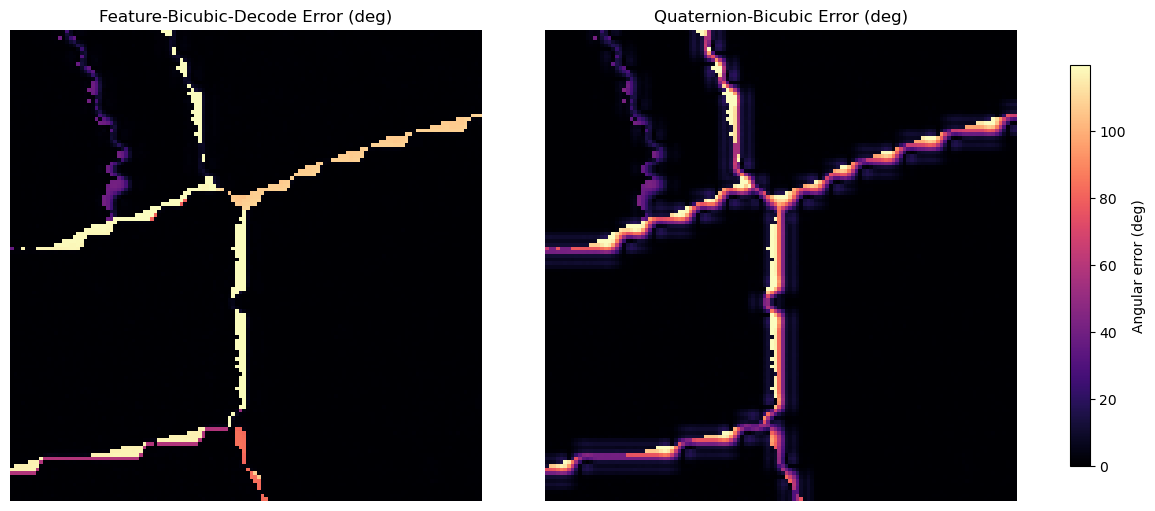

In [ ]:
err_feat_np = err_feat_deg.detach().cpu().numpy()
err_bic_np = err_bic_deg.detach().cpu().numpy()

vmax = float(np.percentile(np.concatenate([err_feat_np.ravel(), err_bic_np.ravel()]), 99))
vmax = max(vmax, 1e-3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
im0 = axes[0].imshow(err_feat_np, cmap='magma', vmin=0.0, vmax=vmax)
axes[0].set_title('Feature-Bicubic-Decode Error (deg)')
axes[0].axis('off')

im1 = axes[1].imshow(err_bic_np, cmap='magma', vmin=0.0, vmax=vmax)
axes[1].set_title('Quaternion-Bicubic Error (deg)')
axes[1].axis('off')

fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.85, label='Angular error (deg)')
plt.show()

## Three Test Plots (First 3 Test Samples)

Running inline plots for test indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Processing sample 0...
Processing sample 1...
Processing sample 2...
Processing sample 3...
Processing sample 4...
Processing sample 5...
Processing sample 6...
Processing sample 7...
Processing sample 8...
Processing sample 9...

Per-sample error summaries:

Sample 0
  Feature-bicubic-decode: mean=4.994 deg, median=0.424 deg, p90=1.187 deg, p95=6.193 deg, max=172.305 deg
  Quaternion-bicubic: mean=6.046 deg, median=0.352 deg, p90=10.887 deg, p95=39.855 deg, max=179.848 deg

Sample 1
  Feature-bicubic-decode: mean=7.552 deg, median=0.444 deg, p90=1.193 deg, p95=72.733 deg, max=179.772 deg
  Quaternion-bicubic: mean=8.066 deg, median=0.402 deg, p90=14.152 deg, p95=58.113 deg, max=179.340 deg

Sample 2
  Feature-bicubic-decode: mean=13.878 deg, median=0.471 deg, p90=8.374 deg, p95=178.473 deg, max=179.997 deg
  Quaternion-bicubic: mean=14.788 deg, median=0.583 deg, p90=47.676 deg, p95=107.306 deg, max=179.999 deg

Samp

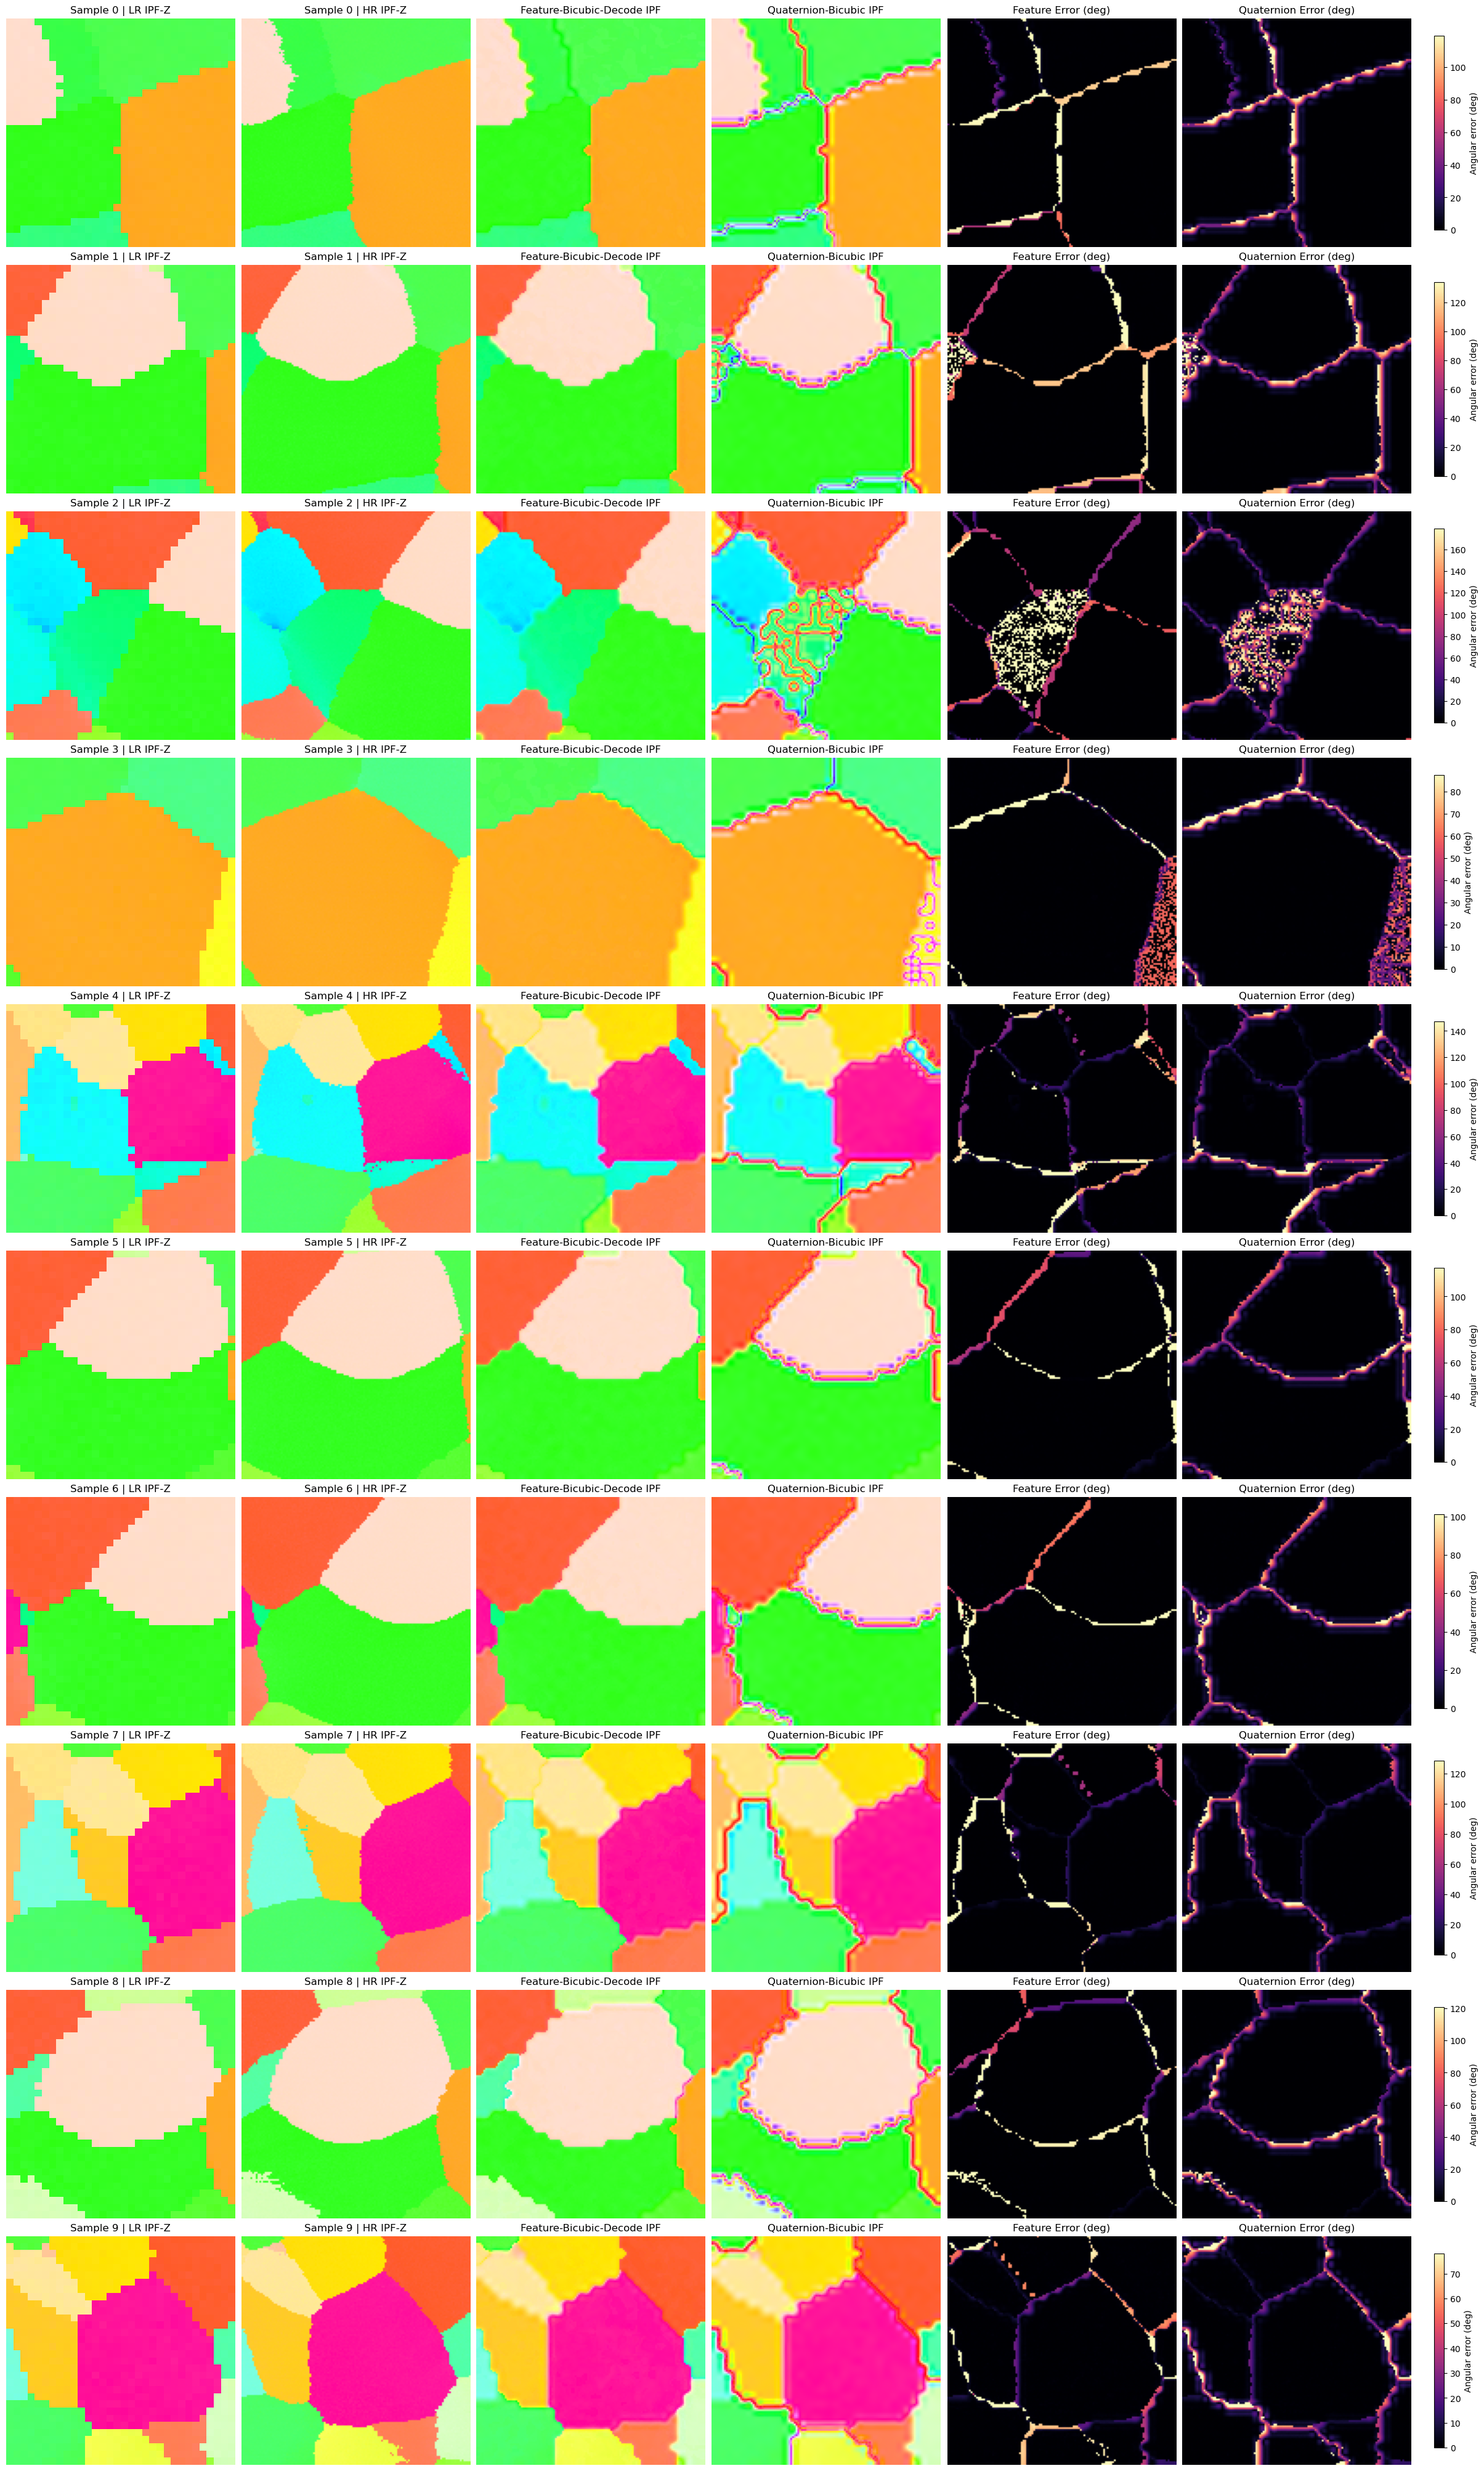

In [ ]:
# Run the full comparison pipeline for multiple test samples and plot inline in the notebook.

from utils.symmetry_utils import resolve_symmetry
from visualization.ipf_render import render_ipf_rgb


sym_class = resolve_symmetry(getattr(cfg, 'symmetry_group', 'D6h'))
IPF_REF_DIR = 'Z'  # use X, Y, Z, or ALL


def run_pipeline_for_sample(sample_index: int):
    lr_raw_i, hr_raw_i = ds[sample_index]

    lr_i = normalize_quat(to_hwc_quat(lr_raw_i).to(device=device, dtype=torch.float32))
    hr_i = normalize_quat(to_hwc_quat(hr_raw_i).to(device=device, dtype=torch.float32))

    h_lr_i, w_lr_i = int(lr_i.shape[0]), int(lr_i.shape[1])
    h_hr_i, w_hr_i = int(hr_i.shape[0]), int(hr_i.shape[1])

    # Feature-space path
    with torch.no_grad():
        lr_flat_i = lr_i.reshape(h_lr_i * w_lr_i, 4)
        feat_lr_flat_i = model.encode_a1(lr_flat_i)

    c_feat_i = int(feat_lr_flat_i.shape[-1])
    feat_lr_img_i = feat_lr_flat_i.reshape(h_lr_i, w_lr_i, c_feat_i).permute(2, 0, 1).unsqueeze(0)
    feat_hr_img_i = F.interpolate(
        feat_lr_img_i,
        size=(h_hr_i, w_hr_i),
        mode='bicubic',
        align_corners=False,
    )
    feat_hr_flat_i = feat_hr_img_i.squeeze(0).permute(1, 2, 0).reshape(h_hr_i * w_hr_i, c_feat_i)

    with torch.enable_grad():
        q_feat_flat_i = model.decode(feat_hr_flat_i)
    q_feat_i = normalize_quat(q_feat_flat_i.reshape(h_hr_i, w_hr_i, 4))

    # Direct quaternion bicubic path
    q_lr_chw_i = to_chw_quat(lr_i).unsqueeze(0)
    q_bic_chw_i = F.interpolate(
        q_lr_chw_i,
        size=(h_hr_i, w_hr_i),
        mode='bicubic',
        align_corners=False,
    ).squeeze(0)
    q_bic_i = normalize_quat(q_bic_chw_i.permute(1, 2, 0))

    # TODOL CHECK FZ ON THESE QUATS
    # with torch.no_grad():
    #     q_bic_i = model.reduce_to_fz(q_bic_i.reshape(-1, 4)).reshape(h_hr_i, w_hr_i, 4)

    # Errors
    err_feat_i = quat_ang_err_deg(q_feat_i, hr_i)
    err_bic_i = quat_ang_err_deg(q_bic_i, hr_i)

    # IPF images (inline display)
    lr_np = lr_i.detach().cpu().numpy().astype(np.float32)
    hr_np = hr_i.detach().cpu().numpy().astype(np.float32)
    feat_np = q_feat_i.detach().cpu().numpy().astype(np.float32)
    bic_np = q_bic_i.detach().cpu().numpy().astype(np.float32)

    lr_rgb = render_ipf_rgb(lr_np, sym_class, ref_dir=IPF_REF_DIR)
    hr_rgb = render_ipf_rgb(hr_np, sym_class, ref_dir=IPF_REF_DIR)
    feat_rgb = render_ipf_rgb(feat_np, sym_class, ref_dir=IPF_REF_DIR)
    bic_rgb = render_ipf_rgb(bic_np, sym_class, ref_dir=IPF_REF_DIR)

    return {
        'sample_index': sample_index,
        'err_feat_deg': err_feat_i,
        'err_bic_deg': err_bic_i,
        'lr_rgb': lr_rgb,
        'hr_rgb': hr_rgb,
        'feat_rgb': feat_rgb,
        'bic_rgb': bic_rgb,
    }


num_plot = min(int(NUM_TEST_PLOTS), len(ds))
sample_indices = list(range(num_plot))
print(f'Running inline plots for test indices: {sample_indices}')

multi_results = []
for sid in sample_indices:
    print(f'Processing sample {sid}...')
    multi_results.append(run_pipeline_for_sample(sid))

print()
print('Per-sample error summaries:')
for res in multi_results:
    sid = res['sample_index']
    print()
    print(f'Sample {sid}')
    summarize_err('  Feature-bicubic-decode', res['err_feat_deg'])
    summarize_err('  Quaternion-bicubic', res['err_bic_deg'])

# rows = samples, cols = [LR IPF, HR IPF, Feature IPF, Quaternion IPF, Feature err, Quaternion err]
n = len(multi_results)
fig, axes = plt.subplots(n, 6, figsize=(24, 4 * n), constrained_layout=True)
if n == 1:
    axes = np.array([axes])

for r, res in enumerate(multi_results):
    err_feat_np = res['err_feat_deg'].detach().cpu().numpy()
    err_bic_np = res['err_bic_deg'].detach().cpu().numpy()
    vmax = float(np.percentile(np.concatenate([err_feat_np.ravel(), err_bic_np.ravel()]), 99))
    vmax = max(vmax, 1e-3)

    panels = [
        (res['lr_rgb'], f"Sample {res['sample_index']} | LR IPF-{IPF_REF_DIR}"),
        (res['hr_rgb'], f"Sample {res['sample_index']} | HR IPF-{IPF_REF_DIR}"),
        (res['feat_rgb'], 'Feature-Bicubic-Decode IPF'),
        (res['bic_rgb'], 'Quaternion-Bicubic IPF'),
    ]

    for c_idx, (img, title) in enumerate(panels):
        ax = axes[r, c_idx]
        ax.imshow(img)
        ax.set_title(title)
        ax.axis('off')

    ax4 = axes[r, 4]
    ax5 = axes[r, 5]
    im4 = ax4.imshow(err_feat_np, cmap='magma', vmin=0.0, vmax=vmax)
    ax4.set_title('Feature Error (deg)')
    ax4.axis('off')

    im5 = ax5.imshow(err_bic_np, cmap='magma', vmin=0.0, vmax=vmax)
    ax5.set_title('Quaternion Error (deg)')
    ax5.axis('off')

    fig.colorbar(im5, ax=[ax4, ax5], shrink=0.85, label='Angular error (deg)')

plt.show()